<a href="https://colab.research.google.com/github/KannetiDivya/TNSIF_Projects/blob/main/Linear_Logistic_Regression_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving housing.csv to housing (1).csv


In [ ]:
import pandas as pd
df=pd.read_csv("housing.csv")
print(df)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                  41          880           129.0   
1        -122.22     37.86                  21         7099          1106.0   
2        -122.24     37.85                  52         1467           190.0   
3        -122.25     37.85                  52         1274           235.0   
4        -122.25     37.85                  52         1627           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                  25         1665           374.0   
20636    -121.21     39.49                  18          697           150.0   
20637    -121.22     39.43                  17         2254           485.0   
20638    -121.32     39.43                  18         1860           409.0   
20639    -121.24     39.37                  16         2785           616.0   

       population  households  median_income  media

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [ ]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND
20639,-121.24,39.37,16,2785,616.0,1387,530,2.3886,89400,INLAND


In [ ]:
df.shape

(20640, 10)

In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df["ocean_proximity"].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [ ]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  int64  
 3   total_rooms                 20640 non-null  int64  
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  int64  
 6   households                  20640 non-null  int64  
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  int64  
 9   ocean_proximity_INLAND      20640 non-null  bool   
 10  ocean_proximity_ISLAND      20640 non-null  bool   
 11  ocean_proximity_NEAR BAY    20640 non-null  bool   
 12  ocean_proximity_NEAR OCEAN  20640 non-null  bool   
dtypes: bool(4), float64(4), int64(5

In [ ]:
numeric_df = df.select_dtypes(include=["number"])
correlation = numeric_df.corr()
print(correlation)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069120 -0.066484           -0.319026     0.927058   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069120    0.099773    0.055310      -0.015176   
latitude                 -0.066484   -0.108785   -0.071035      -0.079809   
housing_

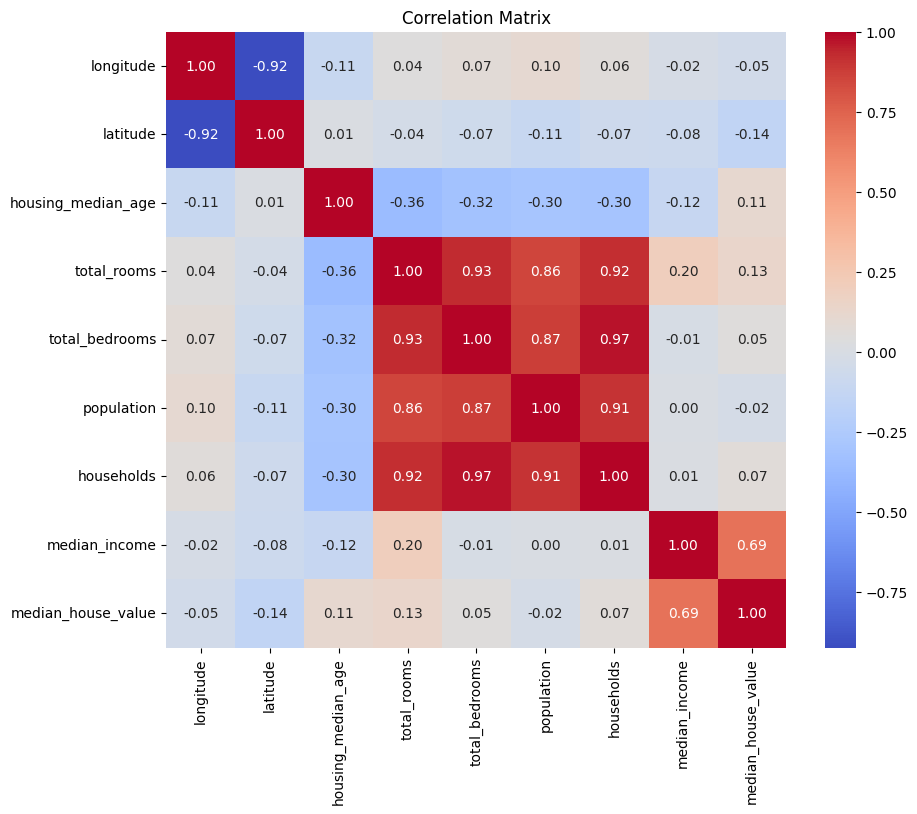

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

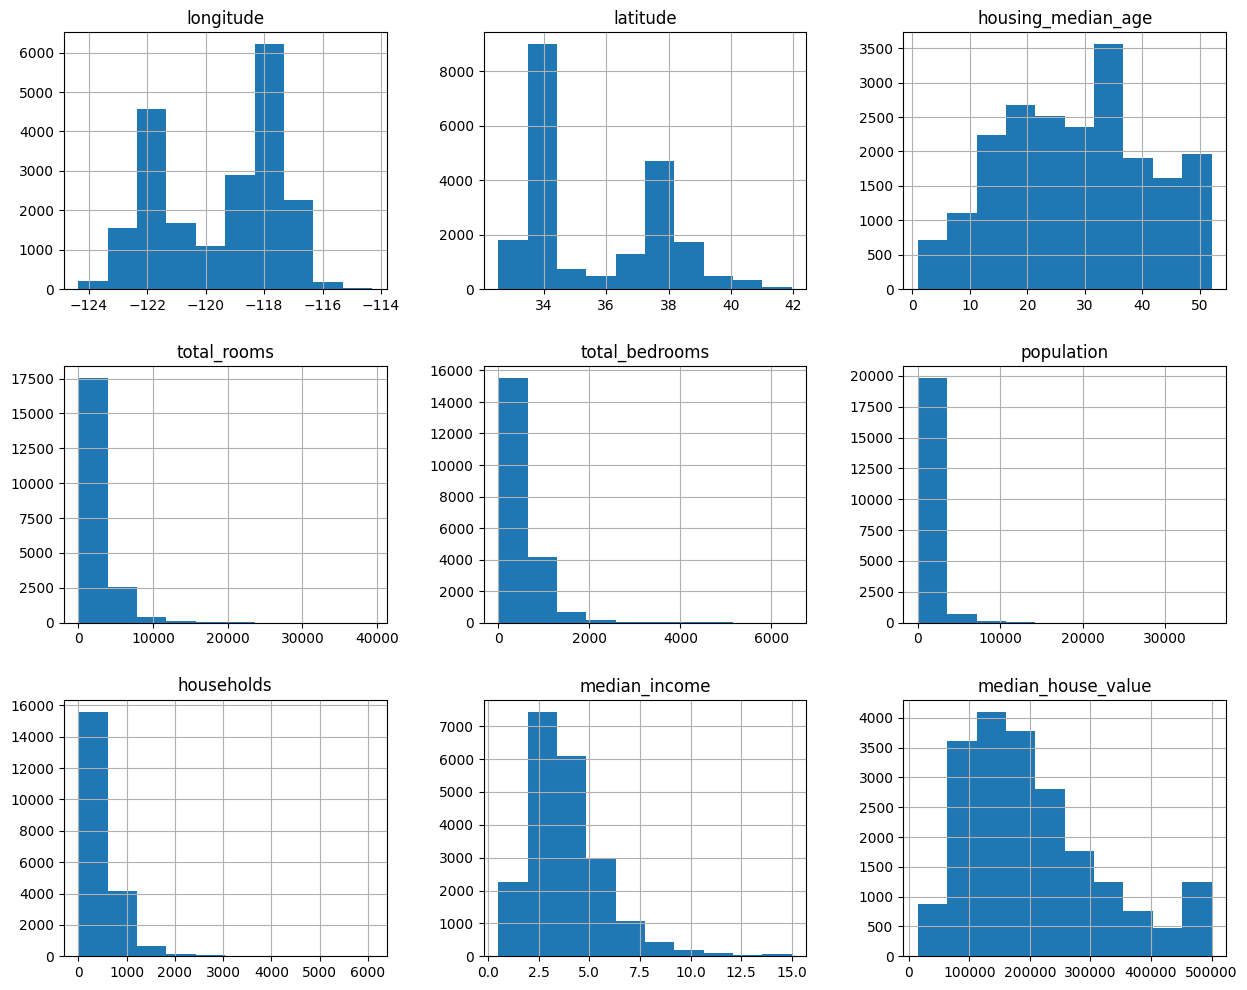

In [ ]:
df.hist(figsize=(15,12))

plt.show()

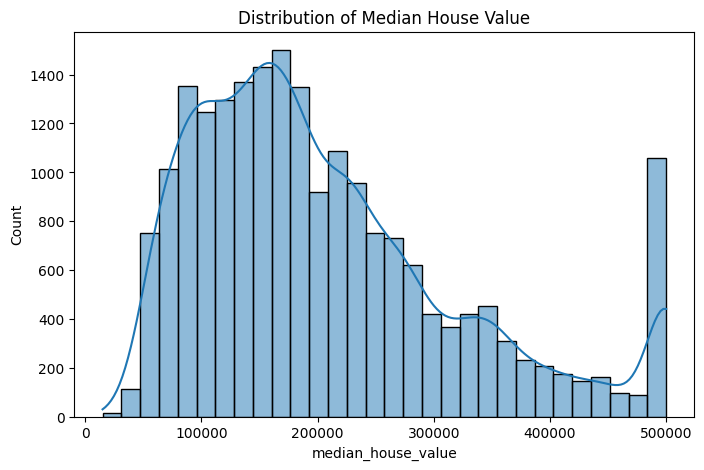

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["median_house_value"],
    bins=30,
    kde=True
)

plt.title("Distribution of Median House Value")

plt.show()

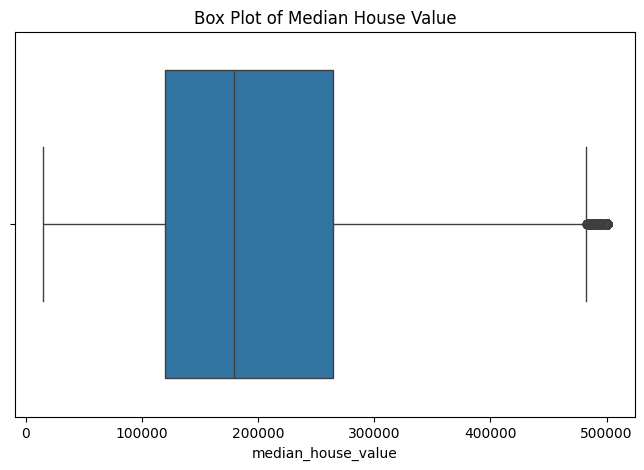

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["median_house_value"]
)

plt.title("Box Plot of Median House Value")

plt.show()

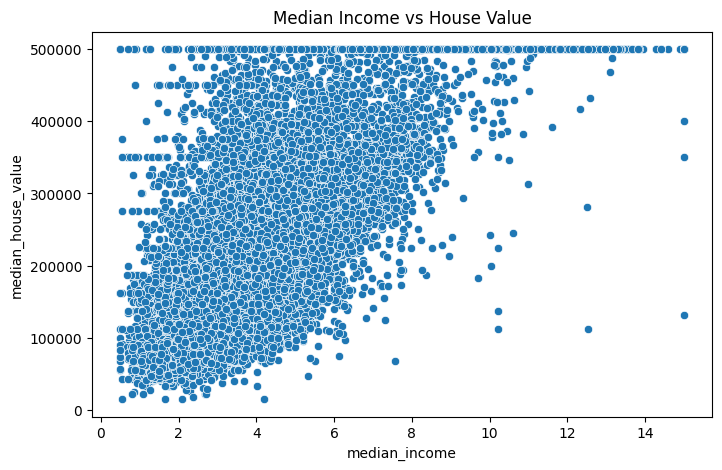

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="median_income",
    y="median_house_value",
    data=df
)

plt.title("Median Income vs House Value")

plt.show()

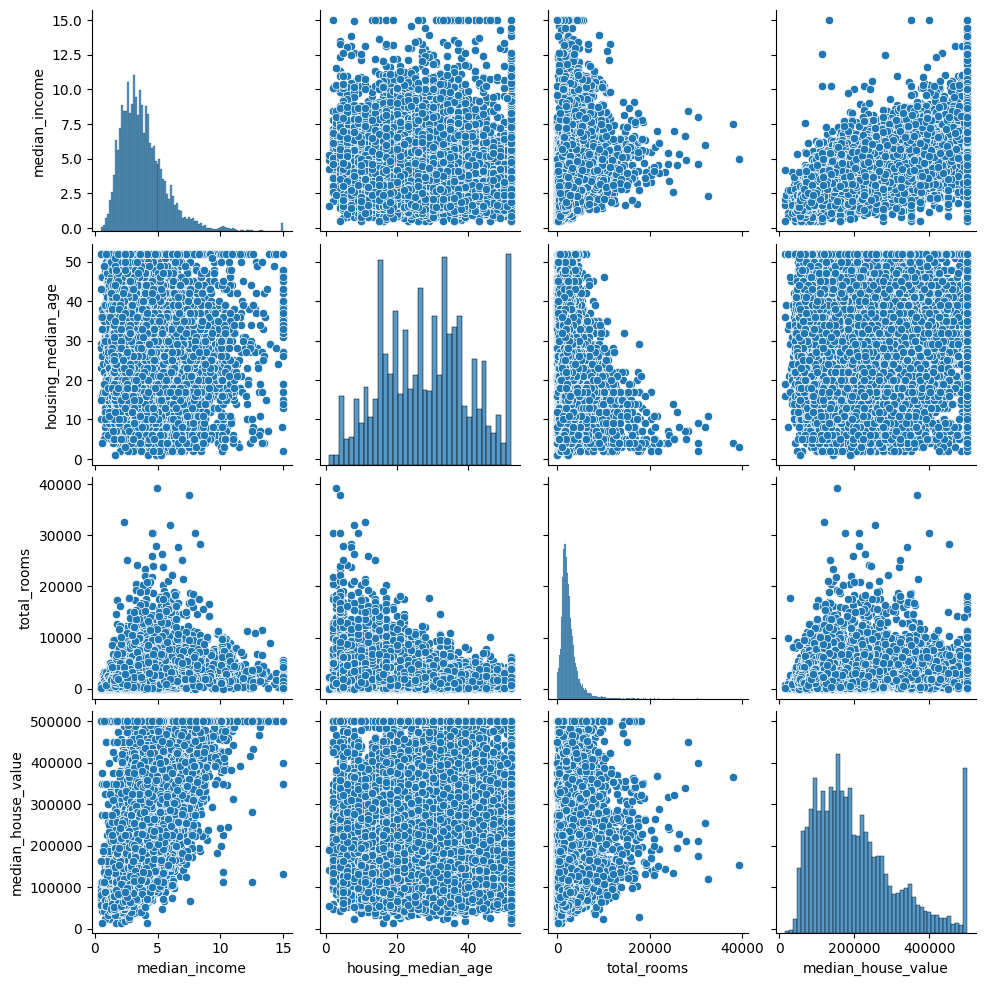

In [ ]:
sns.pairplot(df[
    [
        "median_income",
        "housing_median_age",
        "total_rooms",
        "median_house_value"
    ]
])

plt.show()

In [ ]:
correlation["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049457
population,-0.024650
longitude,-0.045967
latitude,-0.144160


In [ ]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X Train:", X_train.shape)
print("X Test :", X_test.shape)
print("Y Train:", y_train.shape)
print("Y Test :", y_test.shape)

X Train: (16512, 12)
X Test : (4128, 12)
Y Train: (16512,)
Y Test : (4128,)


In [ ]:
#Linear Regression(Regression Task)-Predict the continuous value of Median House Value.
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print(y_pred[:10])

[ 54055.44889899 124225.33893718 255489.37949165 268002.43156918
 262769.43481569 139606.30395558 290665.42391418 228264.8763753
 256506.78561004 407923.85843487]


In [ ]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
20046,47700,54055.448899
3024,45800,124225.338937
15663,500001,255489.379492
20484,218600,268002.431569
9814,278000,262769.434816
13311,158700,139606.303956
7113,198200,290665.423914
7668,157500,228264.876375
18246,340000,256506.785610
5723,446600,407923.858435


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("R2 Score :", r2)

Mean Absolute Error : 50670.73824097229
Mean Squared Error : 4908476721.156606
R2 Score : 0.6254240620553614


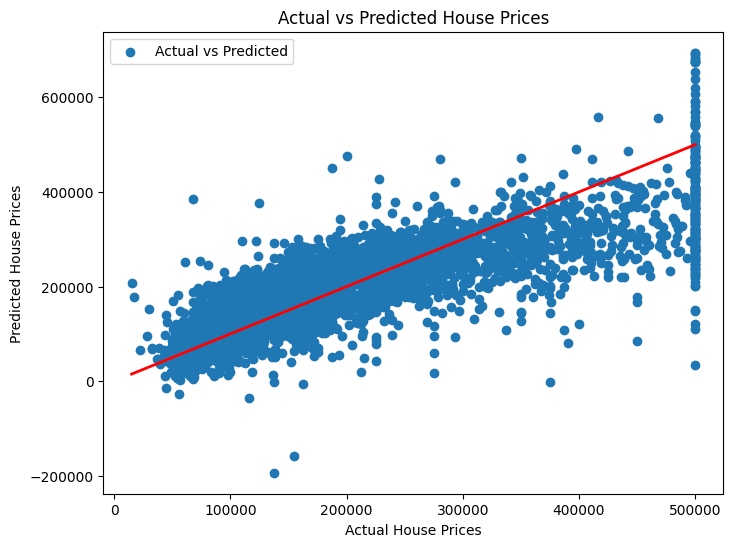

In [ ]:
# Actual vs Predicted Values

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.legend(["Actual vs Predicted"])
plt.title("Actual vs Predicted House Prices")

plt.show()

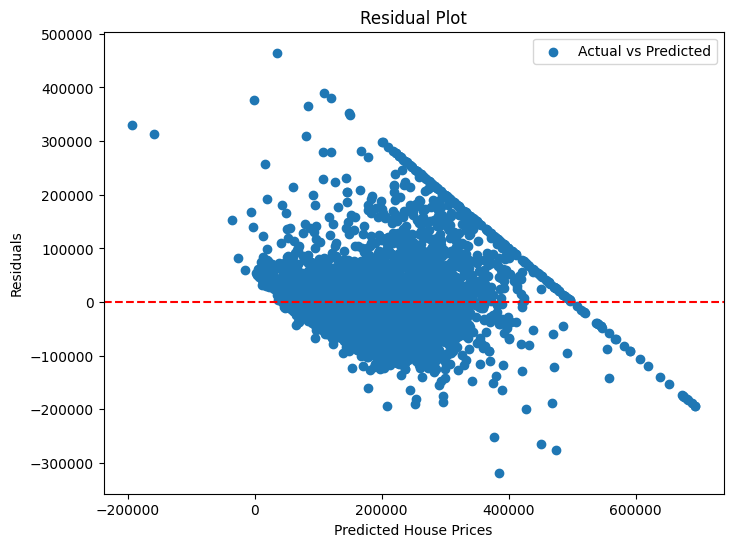

In [ ]:
# Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")
plt.legend(["Actual vs Predicted"])
plt.title("Residual Plot")

plt.show()

In [ ]:
#Logistic Regression(Classification Task): Predict whether a house is "Expensive" or "Not Expensive".
median_value = df["median_house_value"].median()

df["Expensive"] = (df["median_house_value"] > median_value).astype(int)
print(df[["median_house_value","Expensive"]])

       median_house_value  Expensive
0                  452600          1
1                  358500          1
2                  352100          1
3                  341300          1
4                  342200          1
...                   ...        ...
20635               78100          0
20636               77100          0
20637               92300          0
20638               84700          0
20639               89400          0

[20640 rows x 2 columns]


In [ ]:
#Define Features (X) and Target (y)
X = df.drop(["median_house_value", "Expensive"], axis=1)
y = df["Expensive"]

# Verify target contains only 0 and 1
print("Unique values in target:", y.unique())

Unique values in target: [1 0]


In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X Train:", X_train.shape)
print("X Test :", X_test.shape)
print("Y Train:", y_train.shape)
print("Y Test :", y_test.shape)

X Train: (16512, 12)
X Test : (4128, 12)
Y Train: (16512,)
Y Test : (4128,)


In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Model
log_model = LogisticRegression(max_iter=1000)

#Train Model
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_model.predict(X_test_scaled)

print("First 20 Predictions:")
print(y_pred[:20])

First 20 Predictions:
[0 0 1 1 1 0 1 1 1 1 0 0 0 0 1 0 1 0 1 0]


In [ ]:
# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation")
print("-------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Model Evaluation
-------------------------
Accuracy : 0.8328488372093024
Precision: 0.8357178095707942
Recall   : 0.825938566552901
F1 Score : 0.8307994114762138

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.84      0.83      2077
           1       0.84      0.83      0.83      2051

    accuracy                           0.83      4128
   macro avg       0.83      0.83      0.83      4128
weighted avg       0.83      0.83      0.83      4128



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)



Confusion Matrix
[[1744  333]
 [ 357 1694]]


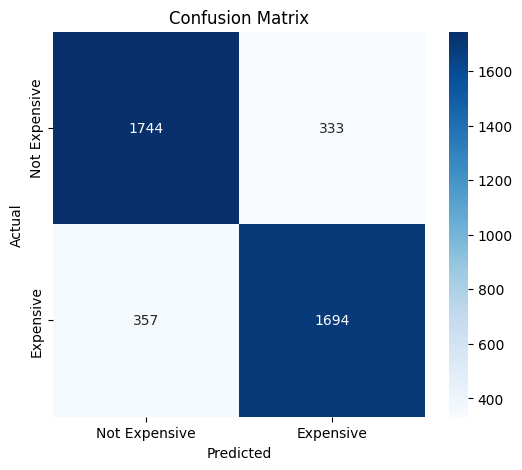

In [ ]:
#Plot Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Expensive", "Expensive"],
    yticklabels=["Not Expensive", "Expensive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Comparison & Reflection

In this assignment, I applied both Linear Regression and Logistic Regression to the California Housing dataset. Linear Regression was used to predict the continuous value of median house prices, while Logistic Regression classified houses into two categories: Expensive and Not Expensive. Linear Regression helped estimate the actual house price, whereas Logistic Regression focused on correctly identifying the category of each house.

Converting the regression problem into a classification problem changed the way model performance was evaluated. For Linear Regression, success was measured using MAE, MSE, and R² Score, which indicate how close the predicted prices are to the actual values. For Logistic Regression, success was measured using Accuracy, Precision, Recall, F1 Score, and the Confusion Matrix, which evaluate how well the model classifies houses into the correct categories. This assignment demonstrated that different machine learning tasks require different evaluation metrics and interpretation, even when working with the same dataset.

Your Assignment Results Summary
Linear Regression
✅ MAE: 50,670.74
✅ MSE: 4,908,476,721.16
✅ R² Score: 0.6254
Logistic Regression
✅ Accuracy: 83.28%
✅ Precision: 83.57%
✅ Recall: 82.59%
✅ F1 Score: 83.08%